In [ ]:
!pip install torch torchvision tqdm torchview
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F, torch.backends.cudnn as cudnn
import torchvision, torchvision.transforms as transforms
import os, argparse, yaml, math, numpy as np
from torch.utils.tensorboard import SummaryWriter
from torchsummary import summary
from datetime import datetime
import torchvision
from torchview import draw_graph
# Ensure this function is at the module level in model.py
from torchvision.transforms import AutoAugment, AutoAugmentPolicy
from torch.utils.data import DataLoader
from torchvision import transforms




def unpickle(file):
    with open(file, 'rb') as fo:
        data_dict = pickle.load(fo, encoding='bytes')
    return data_dict

class CIFARDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data  # shape (N, 3072)
        self.labels = labels  # shape (N,)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx].reshape(3, 32, 32).transpose(1, 2, 0).astype("uint8")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

def load_cifar10_batches(root_dir):
    data_list, labels_list = [], []
    for i in range(1, 6):
        batch_file = os.path.join(root_dir, f"data_batch_{i}")
        batch = unpickle(batch_file)
        data_list.append(batch[b'data'])
        labels_list.extend(batch[b'labels'])
    val_batch = unpickle('/content/drive/MyDrive/DL_Project_Data/Data/cifar-10-python/cifar-10-batches-py/test_batch')
    X_val = val_batch[b'data']
    y_val = val_batch[b'labels']
    X = np.concatenate(data_list, axis=0)
    y = np.array(labels_list)
    return X, y, X_val, y_val

def get_device():
    if torch.cuda.is_available():
        device = "cuda"
    elif torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    print("Using device:", device)
    return device

def get_transforms(normalization=True, augmentation=True, jitter=True):
    train_transform_list = []
    test_transform_list = []
    train_transform_list.append(transforms.ToPILImage())
    test_transform_list.append(transforms.ToPILImage())
    if augmentation:
        train_transform_list.extend([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.AutoAugment(policy=AutoAugmentPolicy.CIFAR10)
        ])
    if jitter:
        train_transform_list.append(transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1))
        #train_transform_list.append(transforms.RandomErasing(p=0.2))
    train_transform_list.append(transforms.ToTensor())
    test_transform_list.append(transforms.ToTensor())

    if normalization:
        norm_transform = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        train_transform_list.append(norm_transform)
        test_transform_list.append(norm_transform)
    train_transforms = transforms.Compose(train_transform_list)
    test_transforms = transforms.Compose(test_transform_list)
    return train_transforms, test_transforms


class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1, conv_kernel_size=3, shortcut_kernel_size=1, drop=0.4):
        """
        Convolutional Layer kernel size Fi
        Skip connection (shortcut) kernel size Ki
        """
        super(BasicBlock, self).__init__()
        self.drop = drop
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=conv_kernel_size, stride=stride, padding=int(conv_kernel_size/2), bias=False)
        self.bn1 = nn.BatchNorm2d(planes,  momentum=0.9)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=conv_kernel_size,stride=1, padding=int(conv_kernel_size/2), bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes,kernel_size=shortcut_kernel_size, stride=stride, padding=int(shortcut_kernel_size/2), bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
        if self.drop: self.dropout = nn.Dropout(self.drop)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        if self.drop: out = self.dropout(out)
        return out

def conv1x1(in_channels,
            out_channels,
            stride=1,
            groups=1,
            bias=False):
    """
    Convolution 1x1 layer.
    Parameters:
    ----------
    in_channels : int
        Number of input channels.
    out_channels : int
        Number of output channels.
    stride : int or tuple/list of 2 int, default 1
        Strides of the convolution.
    groups : int, default 1
        Number of groups.
    bias : bool, default False
        Whether the layer uses a bias vector.
    """
    return nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=1,
        stride=stride,
        groups=groups,
        bias=bias)

class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block from 'Squeeze-and-Excitation Networks,' https://arxiv.org/abs/1709.01507.
    Parameters:
    ----------
    channels : int
        Number of channels.
    reduction : int, default 16
        Squeeze reduction value.
    """
    def __init__(self,
                 channels,
                 reduction=16):
        super(SEBlock, self).__init__()
        mid_cannels = channels // reduction

        self.pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.conv1 = conv1x1(
            in_channels=channels,
            out_channels=mid_cannels,
            bias=True)
        self.activ = nn.ReLU(inplace=True)

        self.conv2 = conv1x1(
            in_channels=mid_cannels,
            out_channels=channels,
            bias=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        w = self.pool(x)
        w = self.conv1(w)
        w = self.activ(w)
        w = self.conv2(w)
        w = self.sigmoid(w)
        x = x * w
        return x


class ResNet(nn.Module):
    def __init__(
            self,
            block,
            num_blocks,
            conv_kernel_sizes=None,
            shortcut_kernel_sizes=None,
            num_classes=10,
            num_channels=32,
            avg_pool_kernel_size=4,
            drop=None,
            squeeze_and_excitation=None):
        super(ResNet, self).__init__()
        self.in_planes = num_channels
        # self.avg_pool_kernel_size = avg_pool_kernel_size
        self.avg_pool_kernel_size = int(32 / (2**(len(num_blocks)-1)))

        """
        # of channels Ci
        """
        self.num_channels = num_channels
        self.conv1 = nn.Conv2d(3, self.num_channels, kernel_size=3,stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(self.num_channels, momentum=0.9)

        self.drop = drop
        self.squeeze_and_excitation = squeeze_and_excitation

        if self.squeeze_and_excitation:
            self.seblock = SEBlock(channels=self.num_channels)

        """
        # of Residual Layers N
        # of Residual Blocks Bi
        """
        self.residual_layers = []
        for n in range(len(num_blocks)):
            stride = 1 if n==0 else 2 # stride=1 for first residual layer, and stride=2 for the remaining layers
            conv_kernel_size = conv_kernel_sizes[n] if conv_kernel_sizes else 3 # setting default kernel size of block's convolutional layers
            shortcut_kernel_size = shortcut_kernel_sizes[n] if shortcut_kernel_sizes else 1 # setting default kernel size of block's skip connection (shortcut) layers
            self.residual_layers.append(self._make_layer(
                                                    block,
                                                    self.num_channels*(2**n),
                                                    num_blocks[n],
                                                    stride=stride,
                                                    conv_kernel_size=conv_kernel_size,
                                                    shortcut_kernel_size=shortcut_kernel_size))

        self.residual_layers = nn.ModuleList(self.residual_layers)
        self.linear = nn.Linear(self.num_channels*(2**n)*block.expansion, num_classes)
        """
        Dropout layer
        """
        if self.drop:
            self.dropout = nn.Dropout(self.drop) # Define proportion or neurons to dropout

    def _make_layer(self, block, planes, num_blocks, stride, conv_kernel_size, shortcut_kernel_size):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride, conv_kernel_size, shortcut_kernel_size, drop=self.drop))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        if self.squeeze_and_excitation: out = self.seblock(out)
        for layer in self.residual_layers:
            out = layer(out)
        """
        Average pool kernel size
        """
        out = F.avg_pool2d(out, self.avg_pool_kernel_size)
        out = out.view(out.size(0), -1)
        if self.drop: out = self.dropout(out)
        out = self.linear(out)
        return out
def model_fn(config_dict):
    model =  ResNet(
            block=BasicBlock,
            num_blocks=config_dict['num_blocks'],
            conv_kernel_sizes=config_dict['conv_kernel_sizes'],
            shortcut_kernel_sizes=config_dict['shortcut_kernel_sizes'],
            num_channels=config_dict['num_channels'],
            avg_pool_kernel_size=config_dict['avg_pool_kernel_size'],
            drop=config_dict['drop'],
            squeeze_and_excitation=config_dict['squeeze_and_excitation']
        )

    total_params = 0
    for x in filter(lambda p: p.requires_grad, model.parameters()):
        total_params += np.prod(x.data.numpy().shape)
    return model, total_params
class EarlyStopping:
    def __init__(self, patience=30, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print("Early stopping triggered!")
                return True
        return False


# def get_transforms(normalization=True, augmentation=True, jitter=False):
#     train_transform_list = []
#     test_transform_list = []
#     train_transform_list.append(transforms.ToPILImage())
#     test_transform_list.append(transforms.ToPILImage())
#     if augmentation:
#         train_transform_list.extend([
#             transforms.RandomCrop(32, padding=4),
#             transforms.RandomHorizontalFlip(),
#             transforms.AutoAugment(policy=AutoAugmentPolicy.CIFAR10),
#             transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
#             transforms.RandomErasing(p=0.2),
#         ])
#     train_transform_list.append(transforms.ToTensor())
#     test_transform_list.append(transforms.ToTensor())

#     if normalization:
#         norm_transform = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
#         train_transform_list.append(norm_transform)
#         test_transform_list.append(norm_transform)

#     train_transforms = transforms.Compose(train_transform_list)
#     test_transforms = transforms.Compose(test_transform_list)
#     return train_transforms, test_transforms


config_dict = {
    'num_blocks' : [5, 4, 3],
    'conv_kernel_sizes' : [3, 3, 3],
    'shortcut_kernel_sizes' : [1, 1, 1],
    'num_channels' : 64,
    'avg_pool_kernel_size' : 8,
    'drop' : 0,
    'squeeze_and_excitation' : 0,
    'grad_clip' : 0.1,
    'max_epochs' : 150,
    'optim' : "sgd",
    'lr_sched' : "CosineAnnealingWarmRestarts",
    'momentum' : 0.9,
    'lr' : 0.002,
    'weight_decay' : 0.0005,
    'batch_size' : 128,
    'num_workers' : 16,
    'data_augmentation' : 1,
    'data_normalize' : 1,
    'lookahead' : 1,
    'label_smoothing' : 0.1,
    'use_amp' : True,
}

In [ ]:

root_dir = "/content/drive/MyDrive/DL_Project_Data/Data/cifar-10-python/cifar-10-batches-py"
X_train, y_train, X_val, y_val = load_cifar10_batches(root_dir)

train_transforms, test_transforms = get_transforms()
train_dataset = CIFARDataset(X_train, y_train, transform=train_transforms)
val_dataset = CIFARDataset(X_val, y_val, transform=test_transforms)
train_loader = DataLoader(
train_dataset,
batch_size=config_dict['batch_size'],
shuffle=True,
num_workers=config_dict['num_workers'],
pin_memory=False
)
val_loader = DataLoader(val_dataset, batch_size=int(config_dict['batch_size']/4), shuffle=False, num_workers=config_dict['num_workers'], pin_memory=False)



In [ ]:
import warnings
from torch.optim import AdamW
warnings.simplefilter("ignore")

device = get_device()

# Sample visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

model, params = model_fn(config_dict)
model = model.to(device)
best_acc = 0  # best test accuracy
start_epoch= 0  # start from epoch 0 or last checkpoint epoch
criterion = nn.CrossEntropyLoss(label_smoothing=config_dict['label_smoothing'])
optimizer = AdamW(model.parameters(), lr=config_dict['lr'], weight_decay=config_dict['weight_decay'])
#optimizer = optim.SGD(model.parameters(), lr=config_dict['lr'], momentum=config_dict["momentum"], weight_decay=config_dict["weight_decay"])
# scheduler = None
#if config_dict["lr_sched"] == 'CosineAnnealingLR': scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2
)

scaler = torch.cuda.amp.GradScaler() if config_dict.get("use_amp", False) else None
early_stopping = EarlyStopping(patience=30, min_delta=0.0001)
if device == 'cuda':
    net = torch.nn.DataParallel(model)
    cudnn.benchmark = True

#extra
metrics_df = pd.DataFrame(columns=['train_loss', 'train_acc', 'val_loss', 'val_acc', 'lr'])
metrics_df.index.name = 'epoch'

# Training
import traceback
try:
    def train(epoch, config):
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        train_losses = []
        train_acc = []
        train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['max_epochs']}", leave=False)  # [NEW]

        for batch_idx, (inputs, targets) in enumerate(train_progress):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            #outputs = model(inputs)
            # loss = criterion(outputs, targets)
            # loss.backward()
            if config.get("use_amp", False):  # [NEW]
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()

                if config["grad_clip"]:
                    nn.utils.clip_grad_value_(model.parameters(), clip_value=config["grad_clip"])
                optimizer.step()

            train_loss += loss.item()
            train_losses.append(train_loss)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            train_acc.append(100.*correct/total)
            train_progress.set_postfix(loss=loss.item())
            # print('Batch_idx: %d | Train Loss: %.3f | Train Acc: %.3f%% (%d/%d)'% (batch_idx, train_loss/(batch_idx+1), 100.*correct/total, correct, total))
        metrics_df.loc[epoch] = [np.mean(train_losses), np.mean(train_acc), np.nan, np.nan, optimizer.param_groups[0]['lr']]  # val_loss and val_acc will be added in the test function
        writer.add_scalar('Loss/train_loss', np.mean(train_losses), epoch)
        writer.add_scalar('Accuracy/train_accuracy', np.mean(train_acc), epoch)
except Exception as e:
    print(f"An error occurred: {e}")
    print(traceback.print_exc())
# Testing
def test(epoch, config, savename):
    global best_acc
    model.eval()
    test_loss = 0
    test_losses = []
    test_acc = []
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(val_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            test_losses.append(test_loss)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            test_acc.append(100.*correct/total)
            # print('Batch_idx: %d | Test Loss: %.3f | Test Acc: %.3f%% (%d/%d)'% ( batch_idx, test_loss/(batch_idx+1), 100.*correct/total, correct, total))
        writer.add_scalar('Loss/test_loss', np.mean(test_losses), epoch)
        writer.add_scalar('Accuracy/test_accuracy', np.mean(test_acc), epoch)

    save_path = os.path.join('/content/drive/MyDrive/DL_Project_Data/', savename)
    # Save checkpoint.
    acc = 100.*correct/total
    if acc > best_acc:
        print('Model saved at best training accuracy :', acc)
        state = {
            'model': model.state_dict(),
            'accuracy': acc,
            'epoch': epoch,
            'config': config
        }
        if not os.path.isdir(save_path):
            os.mkdir(save_path)
        torch.save(state, os.path.join('/content/drive/MyDrive/DL_Project_Data/', savename, 'ckpt.pth'))
        best_acc = acc
    metrics_df.loc[epoch, ['val_loss', 'val_acc']] = [np.mean(test_losses), np.mean(test_acc)]
    return (test_loss / len(val_loader)), int(np.mean(test_acc))

print(f"Using device: {device}")
print(f"Model on GPU: {next(model.parameters()).is_cuda}")
print(f"Total Parameters: {params}")





Using device: cpu
Using device: cpu
Model on GPU: False
Total Parameters: 4771146


In [ ]:

exp = datetime.now().strftime("%Y%m%d_%H%M%S")
savename='attempt3'
writer = SummaryWriter('summaries/'+exp)
for epoch in range(start_epoch, config_dict["max_epochs"]):
    train(epoch, config_dict)
    val_loss, val_acc = test(epoch, config_dict, savename)
    print(f"Epoch {epoch+1}/{config_dict['max_epochs']} Val - Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f}")
    scheduler.step()
    if early_stopping(val_loss):
        break
writer.close()
print("Training complete.")
print(f"Best Validation Accuracy: {best_acc:.2f}%")
metrics_df.to_csv(f'/content/drive/MyDrive/DL_Project_Data/{savename}/training_metrics.csv', index=True)


In [ ]:
#print model grapgh here and save that at "save_path+'img.jps' path"
model_graph = draw_graph(model, input_size=(1, 3, 32, 32), expand_nested=True)
plt.figure(figsize=(20, 20))
plt.imshow(model_graph.visual_graph)
plt.axis('off')
plt.show()
image_path = os.path.join('/content/drive/MyDrive/DL_Project_Data/'+exp, 'model_graph.jpg')
model_graph.visual_graph.savefig(image_path)


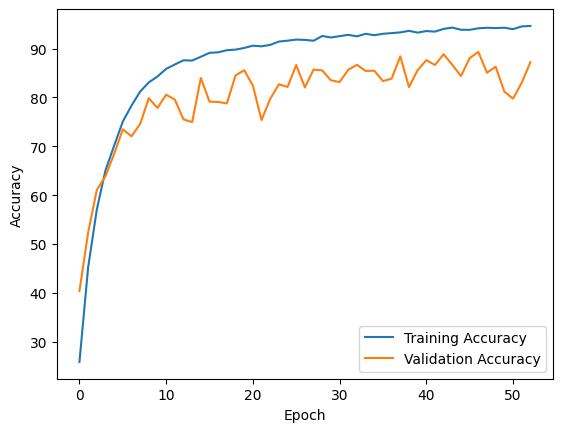

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(metrics_df.index, metrics_df['train_acc'], label='Training Accuracy')
plt.plot(metrics_df.index, metrics_df['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
# ... (similar code for loss) ...

# Plot learning rate
# ... (similar code for learning rate) ...

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
root_dir = "/content/drive/MyDrive/DL_Project_Data/Data/cifar-10-python/cifar-10-batches-py"
X_train, y_train, X_val, y_val = load_cifar10_batches(root_dir)

train_transforms, test_transforms = get_transforms()

batch_size = 256
num_workers = 16 if torch.cuda.is_available() else 4




In [ ]:
# cifar_resnet/inference.py

import os
import pickle
import numpy as np
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
#from model import ResNet18CIFAR



def unpickle(file):
    with open(file, 'rb') as fo:
        data_dict = pickle.load(fo, encoding='bytes')
    return data_dict

class CIFARTestDataset(Dataset):
    def __init__(self, data, ids, transform=None):
        """
        data: numpy array of shape (N, 32, 32, 3)
        ids: array-like of test image IDs
        transform: transforms to apply
        """
        self.data = data
        self.ids = ids
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # If data is stored as (32,32,3)
        img = self.data[idx].astype("uint8")
        img_id = self.ids[idx]
        if self.transform:
            img = self.transform(img)
        return img, img_id

def main():
    # Device selection: CUDA > MPS > CPU
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print("Using device:", device)

    # Load the best model (make sure parameters match training)
    model_path = '/content/drive/MyDrive/DL_Project_Data/attempt3/ckpt.pth'
    model, params = model_fn(config_dict)
    model = model.to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model'])
    model.eval()
    print(f"Model on GPU: {next(model.parameters()).is_cuda}")
    print(f"Total Parameters: {params}")

    # Load custom test set (provided by competition) – adjust path as needed
    # The custom test file should contain keys: b'data' (shape (N, 32,32,3)) and b'ids'
    test_file = "/content/drive/MyDrive/DL_Project_Data/Data/cifar_test_nolabel.pkl"
    test_dict = unpickle(test_file)
    print("Keys in test_dict:", test_dict.keys())

    test_images = test_dict[b'data']  # shape (N, 32, 32, 3)
    test_ids = test_dict[b'ids']

    # Define test transforms (no random augmentation)

    _, transform_test = get_transforms()
    test_dataset = CIFARTestDataset(test_images, test_ids, transform=transform_test)
    test_loader = DataLoader(test_dataset, batch_size=int(256), shuffle=False, num_workers=16)

    # Inference loop
    all_preds = []
    all_ids = []
    with torch.no_grad():
        for images, ids in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy().tolist())
            all_ids.extend(ids.tolist())

    # Create submission CSV (must have exactly two columns: "ID" and "Labels")
    submission_df = pd.DataFrame({
        "ID": all_ids,
        "Labels": all_preds
    })
    submission_df.to_csv("/content/drive/MyDrive/DL_Project_Data/Submissions/submission3_attempt1.csv", index=False)
    print("submission.csv generated! Ready for Kaggle submission.")

main()

Using device: cpu
Model on GPU: False
Total Parameters: 4771146
Keys in test_dict: dict_keys([b'data', b'ids'])
submission.csv generated! Ready for Kaggle submission.
